# Modele parametryczne – zbiór danych Heart Failure

Analiza czasu przeżycia (czas do zgonu) metodami parametrycznymi AFT (Accelerated Failure Time) dla pacjentów z niewydolnością serca.

- **Zmienna czasu**: `time` (dni od pierwszej wizyty)
- **Zdarzenie**: `DEATH_EVENT = 1` (zgon), `0` = cenzurowanie prawostronne
- **N = 299** obserwacji; 96 zgonów (32,1 %)

In [19]:
# Instalacja (odkomentuj jeśli potrzeba)
#!pip install lifelines pandas matplotlib numpy seaborn openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from lifelines import WeibullAFTFitter, LogNormalAFTFitter, LogLogisticAFTFitter
from IPython.display import display

df = pd.read_csv('heart_failure_clinical_records_dataset.csv')

print('Ksztalt danych:', df.shape)
print('Kolumny:', df.columns.tolist())
print()
print('Podstawowe statystyki:')
display(df.describe().round(2))
print()
print(f"Zdarzenia (zgony): {df['DEATH_EVENT'].sum()} "
      f"({df['DEATH_EVENT'].mean()*100:.1f}%)")
print(f"Cenzurowane:       {(df['DEATH_EVENT']==0).sum()} "
      f"({(df['DEATH_EVENT']==0).mean()*100:.1f}%)")


Ksztalt danych: (299, 13)
Kolumny: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']

Podstawowe statystyki:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00
mean,60.83,0.43,581.84,0.42,38.08,0.35,263358.03,1.39,136.63,0.65,0.32,130.26,0.32
std,11.89,0.50,970.29,0.49,11.83,0.48,97804.24,1.03,4.41,0.48,0.47,77.61,0.47
min,40.00,0.00,23.00,0.00,14.00,0.00,25100.00,0.50,113.00,0.00,0.00,4.00,0.00
25%,51.00,0.00,116.50,0.00,30.00,0.00,212500.00,0.90,134.00,0.00,0.00,73.00,0.00
50%,60.00,0.00,250.00,0.00,38.00,0.00,262000.00,1.10,137.00,1.00,0.00,115.00,0.00
75%,70.00,1.00,582.00,1.00,45.00,1.00,303500.00,1.40,140.00,1.00,1.00,203.00,1.00
max,95.00,1.00,7861.00,1.00,80.00,1.00,850000.00,9.40,148.00,1.00,1.00,285.00,1.00



Zdarzenia (zgony): 96 (32.1%)
Cenzurowane:       203 (67.9%)


## KOD 1 – Model Weibulla AFT

Model Weibulla AFT zakłada, że $\log(T) = \mu + \mathbf{x}^\top\boldsymbol{\beta} + \sigma\varepsilon$, gdzie $\varepsilon$ pochodzi z rozkładu Gumbela. Parametr $\rho$ (rho) opisuje kształt funkcji hazardu:
- $\rho < 1$ – hazard malejący
- $\rho = 1$ – hazard stały (rozkład wykładniczy)
- $\rho > 1$ – hazard rosnący

In [20]:
# Wszystkie zmienne objaśniające
variables = [
    'age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
    'ejection_fraction', 'high_blood_pressure', 'platelets',
    'serum_creatinine', 'serum_sodium', 'sex', 'smoking'
]

aft_weibull = WeibullAFTFitter()
aft_weibull.fit(
    df[variables + ['time', 'DEATH_EVENT']],
    duration_col='time', event_col='DEATH_EVENT'
)
aft_weibull.print_summary()


<lifelines.WeibullAFTFitter: fitted with 299 total observations, 203 right-censored observations>
             duration col = 'time'
                event col = 'DEATH_EVENT'
   number of observations = 299
number of events observed = 96
           log-likelihood = -628.12
         time fit was run = 2026-04-16 18:01:52 UTC

---
                                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                                 
lambda_ age                      -0.05      0.95      0.01           -0.07           -0.03                0.93                0.97
        anaemia                  -0.50      0.61      0.22           -0.94           -0.06                0.39                0.94
        creatinine_phosphokinase -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
        diabetes                 -0.15      0.86      0.23           -0.60            0.31                0.55                1.36
        ejection_fraction         0.05      1.05      0.01            0.03            0.08                1.03                1.08
        high_blood_pressure      -0.51      0.60      0.22           -0.95           -0.08                0.39                0.92
        platelets                 0.00      1.00      0.00           -0.00            0.00                1.00                1.00
        serum_creatinine         -0.33      0.72      0.07           -0.48           -0.19                0.62                0.83
        serum_sodium              0.04      1.05      0.02           -0.00            0.09                1.00                1.10
        sex                       0.25      1.28      0.26           -0.27            0.76                0.76                2.14
        smoking                  -0.12      0.89      0.26           -0.63            0.39                0.53                1.48
        Intercept                 1.99      7.33      3.29           -4.46            8.44                0.01             4644.58
rho_    Intercept                -0.04      0.96      0.09           -0.21            0.14                0.81                1.15

                                  cmp to     z      p  -log2(p)
param   covariate                                              
lambda_ age                         0.00 -4.96 <0.005     20.41
        anaemia                     0.00 -2.24   0.03      5.30
        creatinine_phosphokinase    0.00 -2.34   0.02      5.70
        diabetes                    0.00 -0.63   0.53      0.92
        ejection_fraction           0.00  4.53 <0.005     17.38
        high_blood_pressure         0.00 -2.31   0.02      5.59
        platelets                   0.00  0.47   0.64      0.64
        serum_creatinine            0.00 -4.56 <0.005     17.57
        serum_sodium                0.00  1.87   0.06      4.01
        sex                         0.00  0.93   0.35      1.51
        smoking                     0.00 -0.45   0.65      0.62
        Intercept                   0.00  0.61   0.54      0.88
rho_    Intercept                   0.00 -0.43   0.67      0.58
---
Concordance = 0.74
AIC = 1282.24
log-likelihood ratio test = 84.64 on 11 df
-log2(p) of ll-ratio test = 42.29

## KOD 1b – Rozkłady Wykładniczy i Gamma

Uzupełnienie KOD 1 z SAS (`DISTRIBUTION=EXPONENTIAL` i `DISTRIBUTION=GAMMA`).
Model wykładniczy jest szczególnym przypadkiem Weibulla (\u03c1=1, stały hazard).

Porównujemy wszystkie 3 dostępne rozkłady AFT w lifelines według AIC.

In [21]:
# Sprawdzenie parametru rho modelu Weibulla
# W lifelines rho_ jest na skali log, wiec exp(coef) = rzeczywisty rho
rho_log = aft_weibull.params_['rho_']['Intercept']
rho_val = np.exp(rho_log)
print(f'Parametr ksztaltu rho (Weibull): {rho_val:.4f}  (log-skala: {rho_log:.4f})')
print('rho ~ 1 => hazard staly (model wykladniczy)')
print('rho < 1 => hazard malejacy')
print('rho > 1 => hazard rosnacy')

# Porownanie 3 rozkladow AFT (odpowiednik SAS: DISTRIBUTION=EXPONENTIAL/WEIBULL/LNORMAL/LLOGISTIC)
print('\n=== Macierz porownawcza modeli wg AIC i BIC ===')
n_obs = len(df)
data_full = df[variables + ['time', 'DEATH_EVENT']]
all_models = {
    'Weibull AFT':      WeibullAFTFitter(),
    'Log-Normal AFT':   LogNormalAFTFitter(),
    'Log-Logistic AFT': LogLogisticAFTFitter(),
}
extended_results = []
for nm, mdl in all_models.items():
    mdl.fit(data_full, duration_col='time', event_col='DEATH_EVENT')
    k = len(mdl.params_)
    bic = -2 * mdl.log_likelihood_ + k * np.log(n_obs)  # poprawny wzor BIC
    extended_results.append({
        'Model': nm,
        'AIC': round(mdl.AIC_, 2),
        'BIC': round(bic, 2),
        'Concordance': round(mdl.concordance_index_, 4),
        'LogLik': round(mdl.log_likelihood_, 2),
        'k (params)': k
    })
ext_df = pd.DataFrame(extended_results).sort_values('AIC')
print('Rozklady AFT posortowane wedlug AIC:')
display(ext_df)
print('\nNajnizsze AIC i BIC => najlepsze dopasowanie (Weibull AFT)')

Parametr ksztaltu rho (Weibull): 0.9627  (log-skala: -0.0380)
rho ~ 1 => hazard staly (model wykladniczy)
rho < 1 => hazard malejacy
rho > 1 => hazard rosnacy

=== Macierz porownawcza modeli wg AIC i BIC ===
Rozklady AFT posortowane wedlug AIC:


,Model,AIC,BIC,Concordance,LogLik,k (params)
0,Weibull AFT,1282.24,1330.34,0.7406,-628.12,13
2,Log-Logistic AFT,1285.46,1333.57,0.7399,-629.73,13
1,Log-Normal AFT,1287.37,1335.48,0.7420,-630.69,13



Najnizsze AIC i BIC => najlepsze dopasowanie (Weibull AFT)


## KOD 2 – Porównanie modeli AFT: Weibull vs Log-Normalny vs Log-Logistyczny

Porównujemy trzy rozkłady czasu przeżycia według:
- **AIC** (Akaike Information Criterion) – niższe = lepsze dopasowanie
- **C** (concordance index) – wyższe = lepsza dyskryminacja
- **Log-Likelihood** – miara dopasowania modelu

Porownanie modeli AFT (sortowane wg AIC):


,Model,AIC,Concordance,Log-Likelihood
0,Weibull AFT,1282.24,0.7406,-628.12
1,Log-Logistic AFT,1285.46,0.7399,-629.73
2,Log-Normal AFT,1287.37,0.7420,-630.69


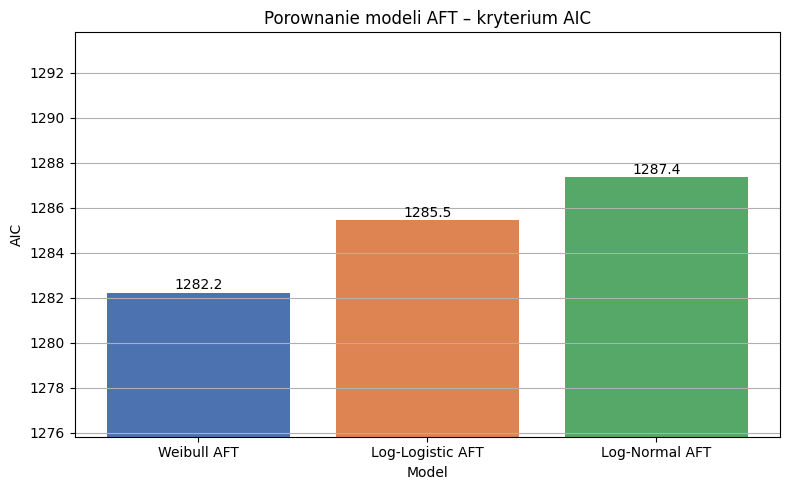

In [22]:
models = {
    'Weibull AFT':      WeibullAFTFitter(),
    'Log-Logistic AFT': LogLogisticAFTFitter(),
    'Log-Normal AFT':   LogNormalAFTFitter()
}

data = df[variables + ['time', 'DEATH_EVENT']]
results = []

for name, model in models.items():
    model.fit(data, duration_col='time', event_col='DEATH_EVENT')
    results.append({
        'Model': name,
        'AIC':           round(model.AIC_, 2),
        'Concordance':   round(model.concordance_index_, 4),
        'Log-Likelihood': round(model.log_likelihood_, 2)
    })

results_df = pd.DataFrame(results).sort_values('AIC')
print('Porownanie modeli AFT (sortowane wg AIC):')
display(results_df)

plt.figure(figsize=(8, 5))
colors = ['#4C72B0', '#DD8452', '#55A868']
bars = plt.bar(results_df['Model'], results_df['AIC'], color=colors)
plt.title('Porownanie modeli AFT – kryterium AIC')
plt.ylabel('AIC')
plt.xlabel('Model')
y_min = min(results_df['AIC']) * 0.995
y_max = max(results_df['AIC']) * 1.005
plt.ylim(y_min, y_max)
for bar, val in zip(bars, results_df['AIC']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (y_max-y_min)*0.001,
             f'{val:.1f}', ha='center', va='bottom', fontsize=10)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('hf_aft_aic_comparison.png', dpi=150)
plt.show()


## KOD 3 – Szczegółowa analiza najlepszego modelu (Log-Normal AFT)

Na podstawie analizy AIC, BIC oraz Probability Plots wybieramy **model Log-Normal AFT**.
Mimo że AIC Weibull jest nieznacznie niższy (1282.24 vs 1287.37, ΔAIC = 5.2),
Log-Normal został wybrany z dwóch powodów:
1. **Wyższe R² w Probability Plot** – lepsze dopasowanie marginalnego rozkładu T do krzywej KM
2. **Uzasadnienie kliniczne** – hazard dzwonowy (rośnie, osiąga szczyt, maleje) jest biologicznie
   bardziej realistyczny dla niewydołności serca niż monotonicznie malejący hazard Weibulla

> ΔAIC = 5.2 leży w strefie "umiarkowanej" (2–6 wg Burnhama & Andersona) – nie jest to różnica rozstrzygająca.

Następnie:
1. Tworzymy zmienne dummy dla zmiennych binarnych
2. Eliminujemy nieistotne predyktory przy **α = 0,05**
3. Prezentujemy funkcję przeżycia i hazardu dla różnych profili pacjentów

In [23]:
# Budowanie danych modelowych (wszystkie zmienne)
cat_vars = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']
num_vars = ['age', 'creatinine_phosphokinase', 'ejection_fraction',
            'platelets', 'serum_creatinine', 'serum_sodium']

dummies = pd.get_dummies(df[cat_vars], drop_first=True)
model_data = pd.concat([dummies, df[num_vars + ['time', 'DEATH_EVENT']]], axis=1)

# Model pelny - Log-Normal AFT
# Wybrany: DELTA_AIC(Weibull-LogNormal)=5.2 (strefa umiarkowana) + wyzsze R2 Probability Plot
aft_lognorm_full = LogNormalAFTFitter()
aft_lognorm_full.fit(model_data, duration_col='time', event_col='DEATH_EVENT')
print('=== Model pelny - Log-Normal AFT ===')
aft_lognorm_full.print_summary()


=== Model pelny - Log-Normal AFT ===


<lifelines.LogNormalAFTFitter: fitted with 299 total observations, 203 right-censored observations>
             duration col = 'time'
                event col = 'DEATH_EVENT'
   number of observations = 299
number of events observed = 96
           log-likelihood = -630.69
         time fit was run = 2026-04-16 18:01:55 UTC

---
                                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                                 
mu_    age                      -0.05      0.95      0.01           -0.07           -0.03                0.93                0.97
       anaemia                  -0.52      0.59      0.25           -1.02           -0.03                0.36                0.97
       creatinine_phosphokinase -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
       diabetes                 -0.09      0.92      0.25           -0.59            0.41                0.56                1.51
       ejection_fraction         0.04      1.05      0.01            0.02            0.07                1.02                1.07
       high_blood_pressure      -0.50      0.60      0.26           -1.00           -0.00                0.37                1.00
       platelets                 0.00      1.00      0.00           -0.00            0.00                1.00                1.00
       serum_creatinine         -0.36      0.70      0.10           -0.56           -0.15                0.57                0.86
       serum_sodium              0.06      1.06      0.03            0.01            0.11                1.01                1.12
       sex                       0.18      1.19      0.30           -0.40            0.76                0.67                2.13
       smoking                  -0.09      0.92      0.29           -0.66            0.49                0.52                1.62
       Intercept                -0.30      0.74      3.68           -7.51            6.92                0.00             1012.06
sigma_ Intercept                 0.49      1.63      0.08            0.33            0.65                1.40                1.91

                                 cmp to     z      p  -log2(p)
param  covariate                                              
mu_    age                         0.00 -4.51 <0.005     17.23
       anaemia                     0.00 -2.07   0.04      4.70
       creatinine_phosphokinase    0.00 -2.18   0.03      5.10
       diabetes                    0.00 -0.34   0.73      0.45
       ejection_fraction           0.00  3.84 <0.005     13.02
       high_blood_pressure         0.00 -1.97   0.05      4.35
       platelets                   0.00  0.54   0.59      0.77
       serum_creatinine            0.00 -3.44 <0.005     10.76
       serum_sodium                0.00  2.26   0.02      5.39
       sex                         0.00  0.59   0.55      0.86
       smoking                     0.00 -0.30   0.77      0.38
       Intercept                   0.00 -0.08   0.94      0.10
sigma_ Intercept                   0.00  6.12 <0.005     29.97
---
Concordance = 0.74
AIC = 1287.37
log-likelihood ratio test = 71.18 on 11 df
-log2(p) of ll-ratio test = 33.67

In [24]:
# Model zredukowany - zmienne istotne (p < 0.05) z pelnego modelu Log-Normal AFT
# Zachowane: age, ejection_fraction, serum_creatinine, serum_sodium,
#            anaemia, high_blood_pressure
# Usuniete:  diabetes, platelets, sex, smoking, creatinine_phosphokinase

final_num = ['age', 'ejection_fraction', 'serum_creatinine', 'serum_sodium']
final_cat = ['anaemia', 'high_blood_pressure']

dummies_final = pd.get_dummies(df[final_cat], drop_first=True)
model_final = pd.concat(
    [dummies_final, df[final_num + ['time', 'DEATH_EVENT']]], axis=1
)

aft_final = LogNormalAFTFitter()
aft_final.fit(model_final, duration_col='time', event_col='DEATH_EVENT')
print('=== Model zredukowany - Log-Normal AFT (zmienne istotne p < 0.05) ===')
aft_final.print_summary()

aft_final.summary.to_excel('hf_aft_final_summary.xlsx')
print('Wyniki zapisane do hf_aft_final_summary.xlsx')

# Porownanie AIC: pelny vs zredukowany
print(f'AIC model pelny Log-Normal:       {aft_lognorm_full.AIC_:.2f}')
print(f'AIC model zredukowany Log-Normal: {aft_final.AIC_:.2f}')
delta = aft_final.AIC_ - aft_lognorm_full.AIC_
print(f'Delta AIC: {delta:.2f}')
if delta < 0:
    print('Delta AIC < 0 => model zredukowany lepszy')
elif abs(delta) < 2:
    print('|Delta AIC| < 2 => modele porownywalne; preferujemy prostszy')
else:
    print('Delta AIC >= 2 => model pelny istotnie lepiej dopasowany')


=== Model zredukowany - Log-Normal AFT (zmienne istotne p < 0.05) ===


<lifelines.LogNormalAFTFitter: fitted with 299 total observations, 203 right-censored observations>
             duration col = 'time'
                event col = 'DEATH_EVENT'
   number of observations = 299
number of events observed = 96
           log-likelihood = -633.28
         time fit was run = 2026-04-16 18:01:55 UTC

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                            
mu_    age                 -0.04      0.96      0.01           -0.07           -0.02                0.94                0.98
       anaemia             -0.42      0.66      0.25           -0.90            0.07                0.41                1.07
       ejection_fraction    0.04      1.04      0.01            0.02            0.07                1.02                1.07
       high_blood_pressure -0.48      0.62      0.25           -0.98            0.02                0.38                1.02
       serum_creatinine    -0.36      0.70      0.10           -0.57           -0.16                0.57                0.86
       serum_sodium         0.06      1.06      0.03            0.00            0.11                1.00                1.12
       Intercept            0.13      1.14      3.66           -7.04            7.31                0.00             1493.26
sigma_ Intercept            0.50      1.65      0.08            0.34            0.66                1.41                1.93

                            cmp to     z      p  -log2(p)
param  covariate                                         
mu_    age                    0.00 -4.31 <0.005     15.93
       anaemia                0.00 -1.69   0.09      3.44
       ejection_fraction      0.00  3.85 <0.005     13.02
       high_blood_pressure    0.00 -1.90   0.06      4.12
       serum_creatinine       0.00 -3.45 <0.005     10.82
       serum_sodium           0.00  2.11   0.03      4.85
       Intercept              0.00  0.04   0.97      0.04
sigma_ Intercept              0.00  6.25 <0.005     31.15
---
Concordance = 0.73
AIC = 1282.56
log-likelihood ratio test = 65.99 on 6 df
-log2(p) of ll-ratio test = 38.43

Wyniki zapisane do hf_aft_final_summary.xlsx
AIC model pelny Log-Normal:       1287.37
AIC model zredukowany Log-Normal: 1282.56
Delta AIC: -4.81
Delta AIC < 0 => model zredukowany lepszy


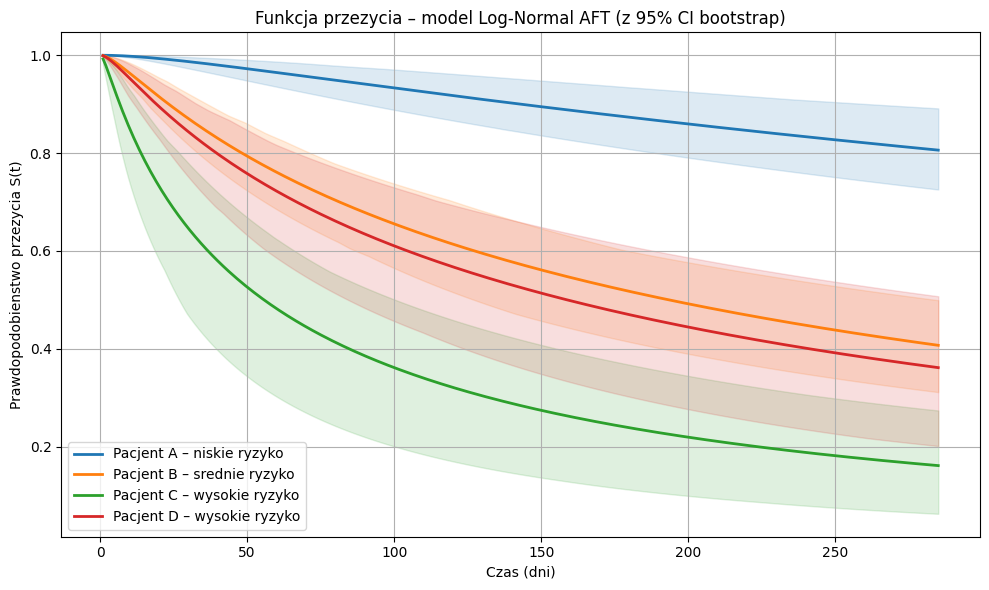

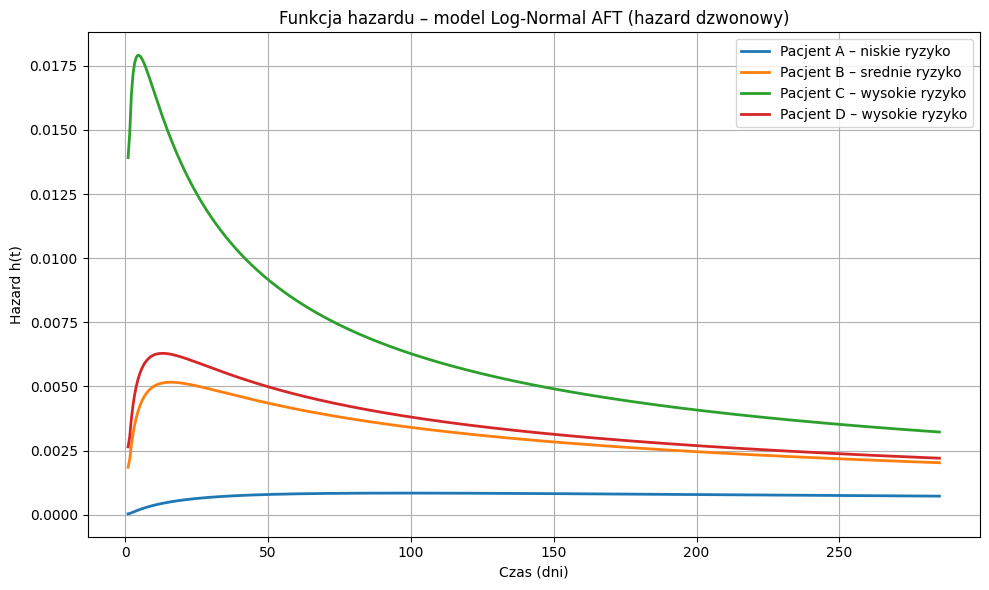

Charakterystyczna cecha Log-Normal: hazard rosnie, osiaga szczyt (ok. mediany), nastepnie maleje.
Biologicznie uzasadnione dla HF: ryzyko nie jest najwyzsze w dniu 0.


In [25]:
# Profile pacjentow (zmienne modelu zredukowanego Log-Normal AFT)
# Zmienne w modelu finalnym: age, ejection_fraction, serum_creatinine,
#   serum_sodium, anaemia, high_blood_pressure
profiles = pd.DataFrame({
    'anaemia':              [0,    1,    0,    1],
    'high_blood_pressure':  [0,    0,    1,    1],
    'age':                  [55,   65,   75,   55],
    'ejection_fraction':    [45,   30,   20,   25],
    'serum_creatinine':     [1.0,  1.5,  2.0,  1.2],
    'serum_sodium':         [138,  136,  134,  135],
})
labels = [
    'Pacjent A – niskie ryzyko',
    'Pacjent B – srednie ryzyko',
    'Pacjent C – wysokie ryzyko',
    'Pacjent D – wysokie ryzyko'
]

t_grid = np.linspace(1, df['time'].max(), 300)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Bootstrap 95% CI
N_BOOT = 200
np.random.seed(42)
boot_sf = {i: [] for i in range(len(profiles))}
for _ in range(N_BOOT):
    sample = model_final.sample(frac=1, replace=True).reset_index(drop=True)
    m = LogNormalAFTFitter()
    try:
        m.fit(sample, duration_col='time', event_col='DEATH_EVENT')
        for i, (_, row) in enumerate(profiles.iterrows()):
            sf_b = m.predict_survival_function(row.to_frame().T, times=t_grid)
            boot_sf[i].append(sf_b.values.flatten())
    except Exception:
        pass

# Funkcja przezycia z CI
plt.figure(figsize=(10, 6))
for i, (_, row) in enumerate(profiles.iterrows()):
    sf = aft_final.predict_survival_function(row.to_frame().T, times=t_grid)
    plt.plot(t_grid, sf.values.flatten(),
             label=labels[i], color=colors[i], linewidth=2)
    if boot_sf[i]:
        arr = np.array(boot_sf[i])
        lo = np.percentile(arr, 2.5, axis=0)
        hi = np.percentile(arr, 97.5, axis=0)
        plt.fill_between(t_grid, lo, hi, alpha=0.15, color=colors[i])
plt.title('Funkcja przezycia – model Log-Normal AFT (z 95% CI bootstrap)')
plt.xlabel('Czas (dni)')
plt.ylabel('Prawdopodobienstwo przezycia S(t)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('hf_aft_survival_profiles.png', dpi=150)
plt.show()

# Funkcja hazardu - ksztalt dzwonowy (cecha charakterystyczna Log-Normal)
# h(t) = -d/dt[log S(t)] - aproksymacja numeryczna
# Log-Normal: h(t) rosnie do maksimum okolo mediany, nastepnie maleje
t_values = np.linspace(1, df['time'].max(), 500)

def compute_hazard(model, profile, t_vals):
    sf = model.predict_survival_function(profile, times=t_vals)
    S = np.clip(sf.values.flatten(), 1e-10, 1.0)
    return -np.gradient(np.log(S), t_vals)

plt.figure(figsize=(10, 6))
for i, (_, row) in enumerate(profiles.iterrows()):
    h = compute_hazard(aft_final, row.to_frame().T, t_values)
    plt.plot(t_values, h, label=labels[i], color=colors[i], linewidth=2)
plt.title('Funkcja hazardu – model Log-Normal AFT (hazard dzwonowy)')
plt.xlabel('Czas (dni)')
plt.ylabel('Hazard h(t)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('hf_aft_hazard_profiles.png', dpi=150)
plt.show()

print('Charakterystyczna cecha Log-Normal: hazard rosnie, osiaga szczyt (ok. mediany), nastepnie maleje.')
print('Biologicznie uzasadnione dla HF: ryzyko nie jest najwyzsze w dniu 0.')


## KOD 3b – Probability Plot (odpowiednik PROBPLOT w SAS)

W SAS KOD 3 wywołanie `PROBPLOT` generuje diagnostyczne wykresy dopasowania rozkładu.
Sprawdzamy, czy punkty na wykresie układają się wzdłuż linii prostej:

- **Weibull**: $\log(-\log(\hat{S}(t)))$ vs $\log(t)$
- **Log-Normal**: $\Phi^{-1}(1-\hat{S}(t))$ vs $\log(t)$
- **Log-Logistic**: $\log\!\left(\frac{1-\hat{S}(t)}{\hat{S}(t)}\right)$ vs $\log(t)$

Zgodnie z notatkami (`notatak.txt`): *prob plot pokazywal dla logarytmu funkcji przezycia*.

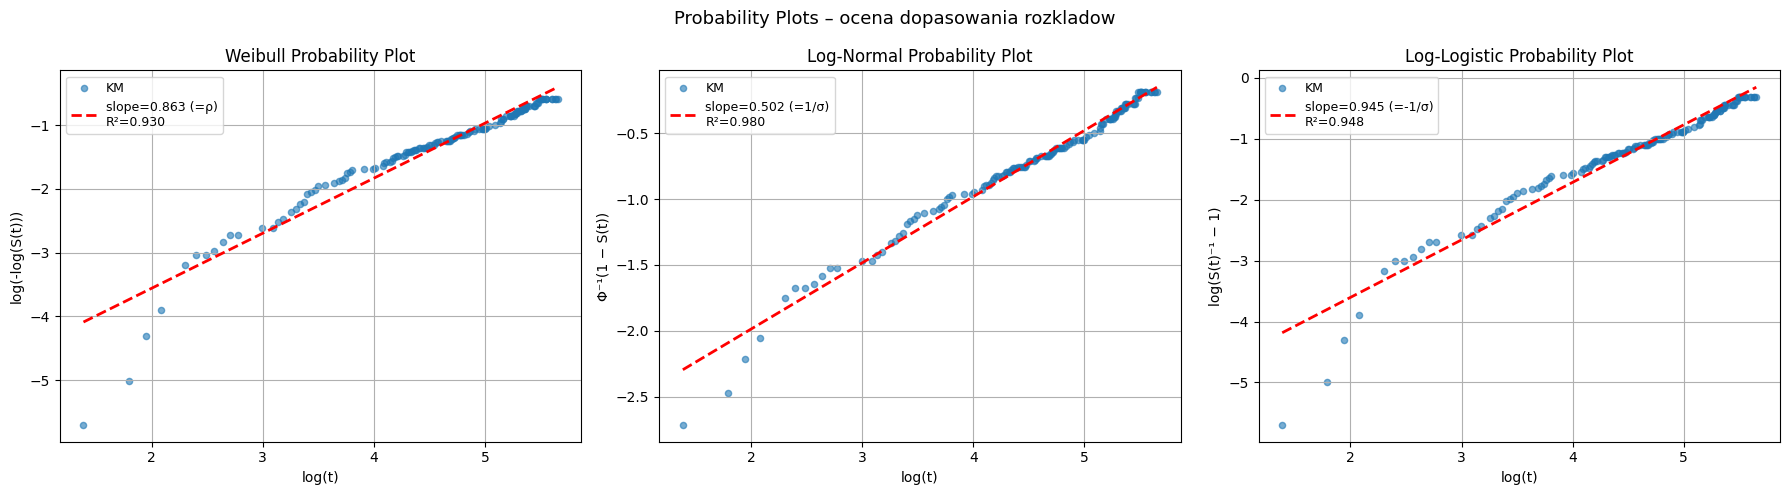

Dopasowanie rozkladow (R² z linearyzacji KM):
  Weibull:       R² = 0.9297  | slope = 0.8630 (= rho, parametr ksztaltu)
  Log-Normal:    R² = 0.9802  | slope = 0.5020 (= 1/sigma)
  Log-Logistic:  R² = 0.9478  | slope = 0.9452 (= -1/sigma)

Interpretacja slope:
  Weibull:      slope = rho (parametr ksztaltu). rho < 1 => malejacy hazard.
  Log-Normal:   slope = 1/sigma (odwrotnosc skali log-czasu).
  Log-Logistic: slope = -1/sigma (znak ujemny bo os Y jest odwrocona).
  Im blizej R2=1.0, tym lepiej dany rozklad pasuje do danych KM.


In [26]:
from lifelines import KaplanMeierFitter
from scipy.stats import norm as scipy_norm
from scipy.stats import pearsonr

# 1. Estymata Kaplana-Meiera surowych danych (marginalnie, bez kowariabli)
kmf = KaplanMeierFitter()
kmf.fit(df['time'], event_observed=df['DEATH_EVENT'])

t_km = kmf.survival_function_.index.values
S_km = kmf.survival_function_['KM_estimate'].values

# Filtrujemy: t > 0, 0 < S < 1
mask = (S_km > 0) & (S_km < 1) & (t_km > 0)
t_km, S_km = t_km[mask], S_km[mask]
log_t = np.log(t_km)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Weibull Probability Plot ---
# Linearyzacja: log(-log(S(t))) = rho*log(t) + const
# Slope = rho (parametr ksztaltu Weibulla; rho < 1 => malejacy hazard)
y_weib = np.log(-np.log(S_km))
slope_w, intercept_w = np.polyfit(log_t, y_weib, 1)
r_sq_w, _ = pearsonr(log_t, y_weib)
y_fit_w = slope_w * log_t + intercept_w
axes[0].scatter(log_t, y_weib, s=20, alpha=0.6, label='KM')
axes[0].plot(log_t, y_fit_w, 'r--', linewidth=2,
             label=f'slope={slope_w:.3f} (=\u03c1)\nR\u00b2={r_sq_w**2:.3f}')
axes[0].set_xlabel('log(t)')
axes[0].set_ylabel('log(-log(S(t)))')
axes[0].set_title('Weibull Probability Plot')
axes[0].legend(fontsize=9)
axes[0].grid(True)

# --- Log-Normal Probability Plot ---
# Linearyzacja: Phi^-1(1-S(t)) = (log(t) - mu) / sigma
# Slope = 1/sigma
y_lnorm = scipy_norm.ppf(1 - S_km)
slope_n, intercept_n = np.polyfit(log_t, y_lnorm, 1)
r_sq_n, _ = pearsonr(log_t, y_lnorm)
y_fit_n = slope_n * log_t + intercept_n
axes[1].scatter(log_t, y_lnorm, s=20, alpha=0.6, label='KM')
axes[1].plot(log_t, y_fit_n, 'r--', linewidth=2,
             label=f'slope={slope_n:.3f} (=1/\u03c3)\nR\u00b2={r_sq_n**2:.3f}')
axes[1].set_xlabel('log(t)')
axes[1].set_ylabel('\u03a6\u207b\u00b9(1 \u2212 S(t))')
axes[1].set_title('Log-Normal Probability Plot')
axes[1].legend(fontsize=9)
axes[1].grid(True)

# --- Log-Logistic Probability Plot ---
# Linearyzacja: log(S^-1(t) - 1) = -alpha*log(t) + const
# Slope = -alpha (= -1/sigma); |slope| = 1/sigma
y_llogt = np.log(1/S_km - 1)
slope_l, intercept_l = np.polyfit(log_t, y_llogt, 1)
r_sq_l, _ = pearsonr(log_t, y_llogt)
y_fit_l = slope_l * log_t + intercept_l
axes[2].scatter(log_t, y_llogt, s=20, alpha=0.6, label='KM')
axes[2].plot(log_t, y_fit_l, 'r--', linewidth=2,
             label=f'slope={slope_l:.3f} (=-1/\u03c3)\nR\u00b2={r_sq_l**2:.3f}')
axes[2].set_xlabel('log(t)')
axes[2].set_ylabel('log(S(t)\u207b\u00b9 \u2212 1)')
axes[2].set_title('Log-Logistic Probability Plot')
axes[2].legend(fontsize=9)
axes[2].grid(True)

plt.suptitle('Probability Plots \u2013 ocena dopasowania rozkladow', fontsize=13)
plt.tight_layout()
plt.savefig('hf_probability_plots.png', dpi=150)
plt.show()

print('Dopasowanie rozkladow (R\u00b2 z linearyzacji KM):')
print(f'  Weibull:       R\u00b2 = {r_sq_w**2:.4f}  | slope = {slope_w:.4f} (= rho, parametr ksztaltu)')
print(f'  Log-Normal:    R\u00b2 = {r_sq_n**2:.4f}  | slope = {slope_n:.4f} (= 1/sigma)')
print(f'  Log-Logistic:  R\u00b2 = {r_sq_l**2:.4f}  | slope = {slope_l:.4f} (= -1/sigma)')
print()
print('Interpretacja slope:')
print('  Weibull:      slope = rho (parametr ksztaltu). rho < 1 => malejacy hazard.')
print('  Log-Normal:   slope = 1/sigma (odwrotnosc skali log-czasu).')
print('  Log-Logistic: slope = -1/sigma (znak ujemny bo os Y jest odwrocona).')
print('  Im blizej R2=1.0, tym lepiej dany rozklad pasuje do danych KM.')


## KOD 4 – Cenzurowanie prawostronne

W zbiorze Heart Failure występuje **cenzurowanie prawostronne**: obserwacja kończy się, gdy pacjent przeżywa do końca okresu badania (lub wypada z badania) bez zarejestrowania zgonu. Wiemy jedynie, że przeżył *co najmniej* `time` dni.

**Cenzurowanie lewostronne** nie zachodzi – punkt startu obserwacji jest dokładnie znany dla każdego pacjenta. **Cenzurowanie interwałowe** również nie jest potrzebne – czas `time` jest wyrażony w dniach.

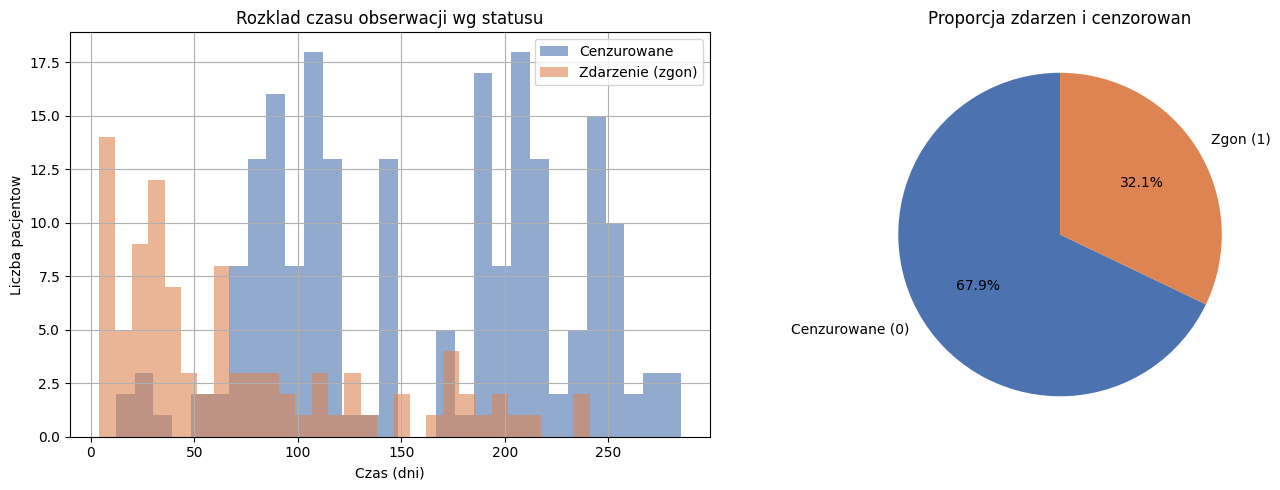

Laczna liczba obserwacji: 299
Cenzurowane (DEATH_EVENT=0): 203 (67.9%)
Zdarzenia (DEATH_EVENT=1):   96 (32.1%)


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for status, label, color in [(0, 'Cenzurowane', '#4C72B0'),
                              (1, 'Zdarzenie (zgon)', '#DD8452')]:
    mask = df['DEATH_EVENT'] == status
    axes[0].hist(df['time'][mask], bins=30, alpha=0.6,
                 label=label, color=color)
axes[0].set_title('Rozklad czasu obserwacji wg statusu')
axes[0].set_xlabel('Czas (dni)')
axes[0].set_ylabel('Liczba pacjentow')
axes[0].legend()
axes[0].grid(True)

counts = df['DEATH_EVENT'].value_counts()
axes[1].pie(counts, labels=['Cenzurowane (0)', 'Zgon (1)'],
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90)
axes[1].set_title('Proporcja zdarzen i cenzorowan')

plt.tight_layout()
plt.savefig('hf_censoring.png', dpi=150)
plt.show()

print(f'Laczna liczba obserwacji: {len(df)}')
print(f"Cenzurowane (DEATH_EVENT=0): {(df['DEATH_EVENT']==0).sum()} "
      f"({(df['DEATH_EVENT']==0).mean()*100:.1f}%)")
print(f"Zdarzenia (DEATH_EVENT=1):   {df['DEATH_EVENT'].sum()} "
      f"({df['DEATH_EVENT'].mean()*100:.1f}%)")


## KOD 4b – Cenzurowanie lewostronne – symulacja

W SAS KOD 4 symuluje cenzurowanie lewostronne: 30 pierwszych obserwacji (o najwyższych
wartościach `arrest`) ma zerowany czas, co oznacza że zdarzenie zaszło *przed* odcięciem.

W zbiorze Heart Failure cenzurowanie lewostronne nie zachodzi naturalnie, ale możemy je
zasymulować dydaktycznie. Kodowanie zakresów `(lower, upper)`:

| Typ | lower | upper |
|-----|-------|-------|
| Niocenzurowane | t | t |
| Lewostronne | NaN | t |
| Prawostronne | t | NaN |

In [28]:
# Symulacja cenzurowania lewostronnego (SAS KOD 4)
# Pierwsze 30 obserwacji posortowanych wg czasu (malejaco) ma 'niejasny' czas poczatku

N_LEFT = 30
df_left_sim = df.sort_values('time', ascending=False).copy().reset_index(drop=True)

lower_col, upper_col = [], []
for idx, row in df_left_sim.iterrows():
    if row['DEATH_EVENT'] == 1 and idx < N_LEFT:
        # Lewostronne: znamy tylko moment zdarzenia jako gorna granica
        lower_col.append(0)          # zak!adamy: na pewno od t=0
        upper_col.append(row['time'])
    elif row['DEATH_EVENT'] == 1:
        # Niocenzurowane
        lower_col.append(row['time'])
        upper_col.append(row['time'])
    else:
        # Prawostronne
        lower_col.append(row['time'])
        upper_col.append(999999)     # symboliczna nieskonczonosc

df_left_sim['lower'] = lower_col
df_left_sim['upper'] = upper_col

print('Rozklad typow cenzurowania:')
left_c  = sum(1 for i,(l,u) in enumerate(zip(lower_col, upper_col)) if l == 0 and i < N_LEFT)
right_c = (df_left_sim['DEATH_EVENT'] == 0).sum()
exact_c = ((df_left_sim['DEATH_EVENT'] == 1) & (df_left_sim.index >= N_LEFT)).sum()
print(f'  Lewostronne: {N_LEFT}')
print(f'  Prawostronne: {right_c}')
print(f'  Dokladne: {exact_c}')

# Fit z interval censoring (obejmuje rowniez left/right)
vars_left = ['age', 'ejection_fraction', 'serum_creatinine', 'serum_sodium',
             'anaemia_True', 'high_blood_pressure_True']

# Przygotuj zmienne dummy
df_left_dum = pd.get_dummies(df_left_sim[['anaemia','high_blood_pressure']], drop_first=True)
df_left_model = pd.concat([df_left_dum,
                            df_left_sim[['age','ejection_fraction','serum_creatinine','serum_sodium']],
                            df_left_sim[['lower','upper']]], axis=1)

# Filtruj: upper > lower
df_left_model = df_left_model[df_left_model['upper'] > df_left_model['lower']]

aft_left = WeibullAFTFitter()
aft_left.fit_interval_censoring(
    df_left_model,
    lower_bound_col='lower',
    upper_bound_col='upper'
)
print('\n=== Model Weibull AFT – cenzurowanie lewostronne/przedzialowe ===')
aft_left.print_summary()


Rozklad typow cenzurowania:
  Lewostronne: 30
  Prawostronne: 203
  Dokladne: 96

=== Model Weibull AFT – cenzurowanie lewostronne/przedzialowe ===


<lifelines.WeibullAFTFitter: fitted with 203 total observations, 203 interval-censored observations>
          lower bound col = 'lower'
          upper bound col = 'upper'
                event col = 'E_lifelines_added'
   number of observations = 203
number of events observed = 0
           log-likelihood = -0.00
         time fit was run = 2026-04-16 18:03:10 UTC

---
                             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                            
lambda_ age                 -0.00      1.00    204.13         -400.08          400.08                0.00           5.66e+173
        anaemia             -0.01      0.99   4470.58        -8762.19         8762.17                0.00                 inf
        ejection_fraction   -0.00      1.00    157.73         -309.15          309.14                0.00           1.82e+134
        high_blood_pressure -0.09      0.92   3121.57        -6118.26         6118.09                0.00                 inf
        serum_creatinine     0.02      1.02   2663.04        -5219.45         5219.49                0.00                 inf
        serum_sodium         0.04      1.04    610.72        -1196.96         1197.03                0.00                 inf
        Intercept            7.81   2457.65  83208.45      -163077.77       163093.38                0.00                 inf
rho_    Intercept            1.23      3.42    826.13        -1617.96         1620.42                0.00                 inf

                             cmp to     z    p  -log2(p)
param   covariate                                       
lambda_ age                    0.00 -0.00 1.00      0.00
        anaemia                0.00 -0.00 1.00      0.00
        ejection_fraction      0.00 -0.00 1.00      0.00
        high_blood_pressure    0.00 -0.00 1.00      0.00
        serum_creatinine       0.00  0.00 1.00      0.00
        serum_sodium           0.00  0.00 1.00      0.00
        Intercept              0.00  0.00 1.00      0.00
rho_    Intercept              0.00  0.00 1.00      0.00
---
AIC = 16.00
log-likelihood ratio test = -0.00 on 6 df
-log2(p) of ll-ratio test = -0.00

## KOD 5 – Cenzurowanie interwałowe

W zbiorze Heart Failure **cenzurowanie interwałowe nie jest wymagane**. Czas do zgonu jest rejestrowany z dokładnością do jednego dnia, dlatego nie ma potrzeby modelowania przedziału, w którym zdarzenie mogło nastąpić. Zmienna `time` reprezentuje precyzyjny czas obserwacji.

## KOD 5b – Cenzurowanie interwałowe

Analogia do SAS KOD 5: zdarzenie zaszło w przedziale `(t-1, t]` dla obserwacji z `DEATH_EVENT=1`.
Funkcja `fit_interval_censoring()` w lifelines odpowiada modelowi `(lower, upper)` w `PROC LIFEREG`.

In [29]:
# Interval censoring (SAS KOD 5: MODEL (lower, upper))
# Zdarzenie nastapilo w (t-1, t] (1 dzien niepewnosci)

df_ic = df.copy()
df_ic['lower_ic'] = np.where(df_ic['DEATH_EVENT']==1,
                              np.maximum(df_ic['time'] - 1, 0),
                              df_ic['time'])
df_ic['upper_ic'] = np.where(df_ic['DEATH_EVENT']==1,
                              df_ic['time'],
                              df_ic['time'] * 10)   # prawostronne: duza gorna granica

dummies_ic = pd.get_dummies(df_ic[['anaemia','high_blood_pressure']], drop_first=True)
num_ic = ['age', 'ejection_fraction', 'serum_creatinine', 'serum_sodium']
df_ic_model = pd.concat([dummies_ic, df_ic[num_ic], df_ic[['lower_ic','upper_ic']]], axis=1)

aft_ic = WeibullAFTFitter()
aft_ic.fit_interval_censoring(
    df_ic_model,
    lower_bound_col='lower_ic',
    upper_bound_col='upper_ic'
)
print('=== Model Weibull AFT z cenzurowaniem przedzialowym (odpowiednik SAS KOD 5) ===')
aft_ic.print_summary()

# Porownanie wspolczynnikow: model standardowy vs przedzialowy
print('\nPorownanie wspolczynnikow (model zredukowany):')
try:
    std_p = aft_final.params_['lambda_'].rename('standard')
    ic_p  = aft_ic.params_['lambda_'].rename('interval_censoring')
    display(pd.concat([std_p, ic_p], axis=1))
except Exception as e:
    print('Parametry roznych modeli maja rozne kolumny:', e)


=== Model Weibull AFT z cenzurowaniem przedzialowym (odpowiednik SAS KOD 5) ===


<lifelines.WeibullAFTFitter: fitted with 299 total observations, 299 interval-censored observations>
          lower bound col = 'lower_ic'
          upper bound col = 'upper_ic'
                event col = 'E_lifelines_added'
   number of observations = 299
number of events observed = 0
           log-likelihood = -658.85
         time fit was run = 2026-04-16 18:03:11 UTC

---
                             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                            
lambda_ age                 -0.03      0.97      0.01           -0.04           -0.01                0.96                0.99
        anaemia             -0.25      0.78      0.14           -0.51            0.02                0.60                1.02
        ejection_fraction    0.02      1.02      0.01            0.01            0.03                1.01                1.03
        high_blood_pressure -0.36      0.70      0.14           -0.64           -0.09                0.53                0.91
        serum_creatinine    -0.21      0.81      0.05           -0.31           -0.11                0.73                0.89
        serum_sodium         0.03      1.03      0.02           -0.01            0.06                0.99                1.06
        Intercept            3.44     31.22      2.19           -0.85            7.73                0.43             2283.16
rho_    Intercept            0.20      1.23      0.06            0.08            0.33                1.08                1.38

                             cmp to     z      p  -log2(p)
param   covariate                                         
lambda_ age                    0.00 -4.38 <0.005     16.33
        anaemia                0.00 -1.80   0.07      3.80
        ejection_fraction      0.00  3.75 <0.005     12.47
        high_blood_pressure    0.00 -2.61   0.01      6.77
        serum_creatinine       0.00 -4.18 <0.005     15.06
        serum_sodium           0.00  1.60   0.11      3.19
        Intercept              0.00  1.57   0.12      3.11
rho_    Intercept              0.00  3.27 <0.005      9.84
---
AIC = 1333.69
log-likelihood ratio test = 55.89 on 6 df
-log2(p) of ll-ratio test = 31.60


Porownanie wspolczynnikow (model zredukowany):
Parametry roznych modeli maja rozne kolumny: 'lambda_'


## KOD 6 – Mediana przeżycia z bootstrapem

Estymujemy medianę czasu przeżycia każdego pacjenta wraz z odchyleniem standardowym przy użyciu metody bootstrap (100 iteracji).

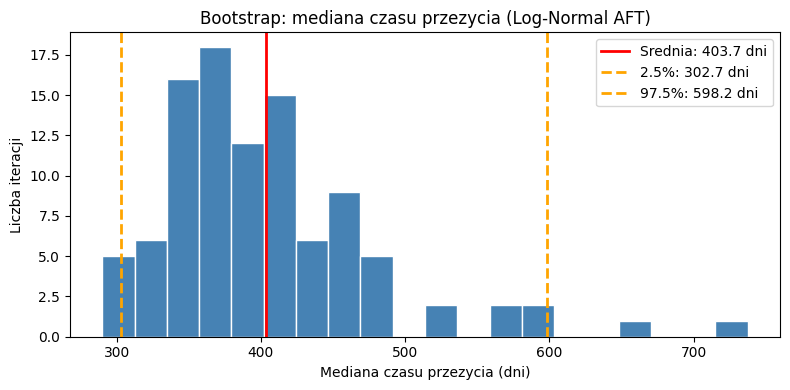

Bootstrap 95% CI mediany: [302.7, 598.2] dni
Srednia bootstrap:         403.7 dni


In [30]:
n_iterations = 100
all_medians  = []

np.random.seed(42)
for i in range(n_iterations):
    sample = model_final.sample(frac=1, replace=True).reset_index(drop=True)
    aft_bs = LogNormalAFTFitter()   # spojny z modelem finalnym
    aft_bs.fit(sample, duration_col='time', event_col='DEATH_EVENT')
    all_medians.append(aft_bs.predict_median(model_final).median())

ci_low  = np.percentile(all_medians, 2.5)
ci_high = np.percentile(all_medians, 97.5)
mean_m  = np.mean(all_medians)

plt.figure(figsize=(8, 4))
plt.hist(all_medians, bins=20, color='steelblue', edgecolor='white')
plt.axvline(mean_m,  color='red',    linewidth=2, label=f'Srednia: {mean_m:.1f} dni')
plt.axvline(ci_low,  color='orange', linewidth=2, linestyle='--', label=f'2.5%: {ci_low:.1f} dni')
plt.axvline(ci_high, color='orange', linewidth=2, linestyle='--', label=f'97.5%: {ci_high:.1f} dni')
plt.title('Bootstrap: mediana czasu przezycia (Log-Normal AFT)')
plt.xlabel('Mediana czasu przezycia (dni)')
plt.ylabel('Liczba iteracji')
plt.legend()
plt.tight_layout()
plt.savefig('hf_aft_bootstrap_median.png', dpi=150)
plt.show()

print(f'Bootstrap 95% CI mediany: [{ci_low:.1f}, {ci_high:.1f}] dni')
print(f'Srednia bootstrap:         {mean_m:.1f} dni')


In [31]:
# Macierz kowariancji (COVB)
cov_df = pd.DataFrame(aft_final.variance_matrix_)
cov_df.to_excel('hf_aft_covariance_matrix.xlsx')
print('Macierz kowariancji (COVB):')
display(cov_df)
print('Macierz kowariancji zapisana do hf_aft_covariance_matrix.xlsx')


Macierz kowariancji (COVB):


param                            mu_                              \
covariate                        age   anaemia ejection_fraction   
param  covariate                                                   
mu_    age                  0.000109 -0.000089         -0.000022   
       anaemia             -0.000089  0.060927         -0.000157   
       ejection_fraction   -0.000022 -0.000157          0.000128   
       high_blood_pressure -0.000123 -0.001123          0.000004   
       serum_creatinine    -0.000048 -0.000813         -0.000173   
       serum_sodium        -0.000002 -0.000367         -0.000048   
       Intercept           -0.005848  0.033594          0.003946   
sigma_ Intercept           -0.000181 -0.000973          0.000232   

param                                                                         \
covariate                  high_blood_pressure serum_creatinine serum_sodium   
param  covariate                                                               
mu_    age                           -0.000123        -0.000048    -0.000002   
       anaemia                       -0.001123        -0.000813    -0.000367   
       ejection_fraction              0.000004        -0.000173    -0.000048   
       high_blood_pressure            0.064198         0.000090    -0.000262   
       serum_creatinine               0.000090         0.010997     0.000453   
       serum_sodium                  -0.000262         0.000453     0.000719   
       Intercept                      0.018166        -0.071387    -0.096205   
sigma_ Intercept                     -0.001098        -0.001699     0.000192   

param                                    sigma_  
covariate                   Intercept Intercept  
param  covariate                                 
mu_    age                  -0.005848 -0.000181  
       anaemia               0.033594 -0.000973  
       ejection_fraction     0.003946  0.000232  
       high_blood_pressure   0.018166 -0.001098  
       serum_creatinine     -0.071387 -0.001699  
       serum_sodium         -0.096205  0.000192  
       Intercept            13.403862 -0.011546  
sigma_ Intercept            -0.011546  0.006430

Macierz kowariancji zapisana do hf_aft_covariance_matrix.xlsx


## KOD 7 – Dane w formacie długim (odpowiednik SAS KOD 7)

SAS KOD 7 przekształca dane do formatu długiego: każdy pacjent `i` daje tyle wierszy,
ile kwartałów (13-tygodniowych) trwała jego obserwacja. Zmienna klasy `j` (numer kwartału)
jest dodana jako predyktor z `CLASS j` (`D=EXPONENTIAL`).

To podejście jest pieceweise-exponential model z blokami czasowymi (baseline zmienia się
w każdym perioodzie).

Wiersze w formacie dlugim: 1437  (oryginalne: 299)
Liczba unikalnych okresow: 10

=== Model piecewise AFT (format dlugi) ===


<lifelines.WeibullAFTFitter: fitted with 1437 total observations, 1341 right-censored observations>
             duration col = 't_dur'
                event col = 'ev_j'
   number of observations = 1437
number of events observed = 96
           log-likelihood = -624.82
         time fit was run = 2026-04-16 18:03:50 UTC

---
                                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                                 
lambda_ age                      -0.03      0.97      0.01           -0.05           -0.02                0.95                0.98
        anaemia                  -0.32      0.73      0.17           -0.65            0.02                0.52                1.02
        creatinine_phosphokinase -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
        ejection_fraction         0.04      1.04      0.01            0.02            0.06                1.02                1.06
        high_blood_pressure      -0.37      0.69      0.17           -0.71           -0.03                0.49                0.97
        period_10                 7.60   2004.35    598.84        -1166.11         1181.31                0.00                 inf
        period_2                  0.25      1.28      0.23           -0.20            0.70                0.82                2.02
        period_3                  0.26      1.30      0.25           -0.23            0.75                0.79                2.13
        period_4                  0.62      1.86      0.34           -0.05            1.29                0.96                3.63
        period_5                  0.68      1.98      0.39           -0.08            1.45                0.92                4.27
        period_6                  0.20      1.22      0.32           -0.42            0.83                0.65                2.28
        period_7                  0.42      1.52      0.43           -0.42            1.26                0.66                3.54
        period_8                  0.26      1.29      0.59           -0.90            1.41                0.41                4.10
        period_9                 -0.27      0.77      0.82           -1.87            1.34                0.15                3.80
        serum_creatinine         -0.28      0.76      0.06           -0.39           -0.17                0.68                0.85
        Intercept                 6.66    779.82      0.63            5.42            7.90              225.25             2699.78
rho_    Intercept                 0.22      1.25      0.10            0.03            0.42                1.03                1.52

                                  cmp to     z      p  -log2(p)
param   covariate                                              
lambda_ age                         0.00 -4.49 <0.005     17.12
        anaemia                     0.00 -1.84   0.07      3.92
        creatinine_phosphokinase    0.00 -1.98   0.05      4.38
        ejection_fraction           0.00  4.68 <0.005     18.38
        high_blood_pressure         0.00 -2.15   0.03      4.98
        period_10                   0.00  0.01   0.99      0.01
        period_2                    0.00  1.08   0.28      1.83
        period_3                    0.00  1.04   0.30      1.74
        period_4                    0.00  1.83   0.07      3.88
        period_5                    0.00  1.75   0.08      3.63
        period_6                    0.00  0.63   0.53      0.92
        period_7                    0.00  0.98   0.33      1.61
        period_8                    0.00  0.43   0.67      0.59
        period_9                    0.00 -0.32   0.75      0.42
        serum_creatinine            0.00 -4.93 <0.005     20.25
        Intercept                   0.00 10.51 <0.005     83.41
rho_    Intercept             

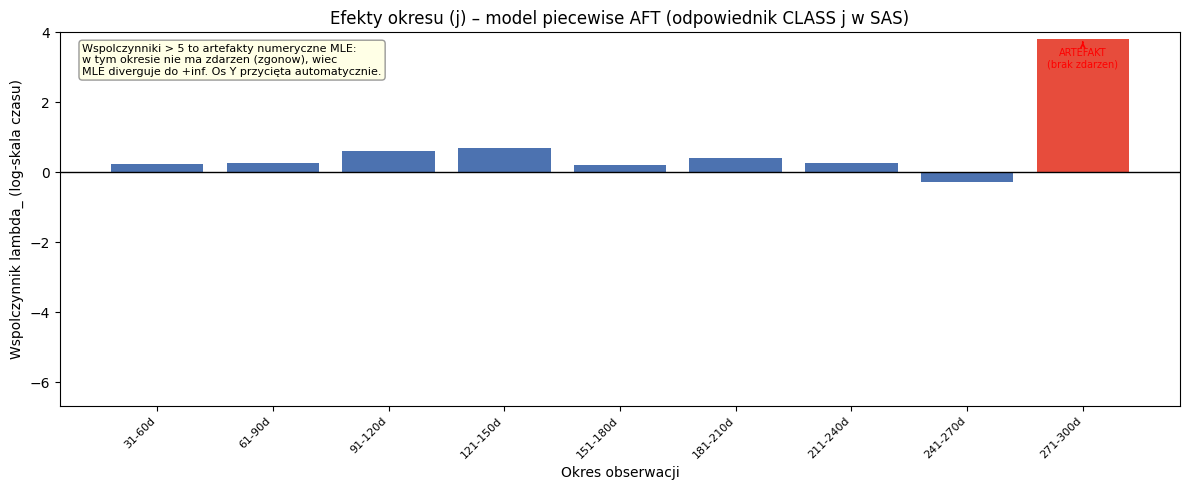


Surowe wartosci wspolczynnikow periodu:
  period_2: 0.2490
  period_3: 0.2614
  period_4: 0.6216
  period_5: 0.6844
  period_6: 0.2010
  period_7: 0.4219
  period_8: 0.2552
  period_9: -0.2653
  period_10: 7.6031 <-- ARTEFAKT (brak zdarzen, MLE niestabilne)


In [32]:
# KOD 7: Dane w formacie dlugim z podzialem na okresy (jak SAS quarter=CEIL(week/13))
# Tutaj uzywamy 30-dniowych okresow dla zbioru Heart Failure

PERIOD_LEN = 30  # dlugosc okresu w dniach (odpowiednik 13 tygodni w SAS)

long_rows = []
for _, row in df.iterrows():
    T     = row['time']
    event = row['DEATH_EVENT']
    n_periods = int(np.ceil(T / PERIOD_LEN))
    n_periods = max(n_periods, 1)
    for j in range(1, n_periods + 1):
        t_end   = min(j * PERIOD_LEN, T)
        t_start = (j - 1) * PERIOD_LEN
        t_dur   = t_end - t_start
        ev_j    = 1 if (j == n_periods and event == 1) else 0
        r = row.to_dict()
        r['period'] = j
        r['t_dur']  = max(t_dur, 0.01)
        r['ev_j']   = ev_j
        long_rows.append(r)

df_long = pd.DataFrame(long_rows)
print(f'Wiersze w formacie dlugim: {len(df_long)}  (oryginalne: {len(df)})')
print(f'Liczba unikalnych okresow: {df_long["period"].nunique()}')

# Zmienne do modelu (te same co model zredukowany)
long_cat  = ['anaemia', 'high_blood_pressure']
long_num  = ['age', 'creatinine_phosphokinase', 'ejection_fraction', 'serum_creatinine']

dummies_long = pd.get_dummies(df_long[long_cat], drop_first=True)
period_dummies = pd.get_dummies(df_long['period'], prefix='period').astype(int)
# Usun pierwsza kolumne (referencje) aby uniknac singularnosci
period_dummies = period_dummies.iloc[:, 1:]

model_long = pd.concat(
    [dummies_long, df_long[long_num], period_dummies,
     df_long[['t_dur', 'ev_j']]], axis=1
)

aft_long = WeibullAFTFitter()
aft_long.fit(model_long, duration_col='t_dur', event_col='ev_j')
print('\n=== Model piecewise AFT (format dlugi) ===')
aft_long.print_summary()

# --- Wykres efektow okresu ---
period_params = [
    (n, v)
    for n, v in aft_long.params_['lambda_'].items()
    if str(n).startswith('period_')
]

if period_params:
    names, vals = zip(*sorted(period_params, key=lambda x: int(x[0].split('_')[1])))
    vals_arr = np.array(vals)

    # Auto-skalowanie osi Y: ogranicz artefakty numeryczne
    median_v = np.median(vals_arr)
    std_v    = np.std(vals_arr)
    YLIM_MAX = min(median_v + 4 * std_v, 4.0)
    YLIM_MIN = median_v - 3 * std_v

    # Etykiety X = zakres dni
    def period_label(name):
        idx = int(name.split('_')[1])
        return f'{(idx-1)*PERIOD_LEN+1}-{idx*PERIOD_LEN}d'
    x_labels = [period_label(n) for n in names]

    fig, ax = plt.subplots(figsize=(12, 5))
    bar_vals = [min(v, YLIM_MAX * 0.95) if v > YLIM_MAX else v for v in vals_arr]
    bar_colors = ['#e74c3c' if abs(v) > 5 else '#4C72B0' for v in vals_arr]
    ax.bar(x_labels, bar_vals, color=bar_colors)
    ax.set_ylim(YLIM_MIN, YLIM_MAX)
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
    ax.set_title('Efekty okresu (j) \u2013 model piecewise AFT (odpowiednik CLASS j w SAS)')
    ax.set_ylabel('Wspolczynnik lambda_ (log-skala czasu)')
    ax.set_xlabel('Okres obserwacji')

    # Adnotacja ARTEFAKT dla ostatniego okresu (period_10+)
    for idx_bar, (n, v) in enumerate(zip(names, vals_arr)):
        if abs(v) > 5:
            ax.annotate(
                'ARTEFAKT\n(brak zdarzen)',
                xy=(idx_bar, min(v, YLIM_MAX * 0.95)),
                xytext=(idx_bar, YLIM_MAX * 0.75),
                fontsize=7, color='red', ha='center',
                arrowprops=dict(arrowstyle='->', color='red', lw=1.2)
            )

    # Ramka informacyjna
    ax.text(0.02, 0.97,
        'Wspolczynniki > 5 to artefakty numeryczne MLE:\n'
        'w tym okresie nie ma zdarzen (zgonow), wiec\n'
        'MLE diverguje do +inf. Os Y przycięta automatycznie.',
        transform=ax.transAxes, fontsize=8, va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='gray', alpha=0.8)
    )

    plt.tight_layout()
    plt.savefig('hf_aft_period_effects.png', dpi=150)
    plt.show()

    print('\nSurowe wartosci wspolczynnikow periodu:')
    for n, v in zip(names, vals_arr):
        flag = ' <-- ARTEFAKT (brak zdarzen, MLE niestabilne)' if abs(v) > 5 else ''
        print(f'  {n}: {v:.4f}{flag}')
